In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Basic_functions as bf
from scipy.sparse import vstack, hstack, csr_matrix, save_npz, load_npz


import torch as pt
import optuna as opt
import sklearn.metrics as skm
import sklearn.utils as sku
from sklearn.preprocessing import StandardScaler

In [2]:
import torch.nn as nn
from torch.nn import CrossEntropyLoss, BCEWithLogitsLoss
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)
import optuna as opt
#from torch.nn import L1Loss
#from scipy.special import expit

W0605 14:30:25.775000 23968 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [ ]:
data_articles_dict = {}
labels_articles_dict = {}
for i in range(19):
    if i < 10:
        data_articles_dict[i] = load_npz(f"Data_files/data_articles_0{i}.npz")
        labels_articles_dict[i] = np.genfromtxt(f"Data_files/labels_articles_0{i}.txt", delimiter="; ", dtype=str)
    else:
        data_articles_dict[i] = load_npz(f"Data_files/data_articles_{i}.npz")
        labels_articles_dict[i] = np.genfromtxt(f"Data_files/labels_articles_{i}.txt", delimiter="; ", dtype=str)

In [ ]:
data_articles = vstack([data_articles_dict[i] for i in range(19)])
labels_articles = np.concatenate([labels_articles_dict[i] for i in range(19)])
data_articles = hstack([labels_articles[:,4].astype(float).reshape(-1, 1), data_articles], format="csr")

In [19]:
#Free the memory used by the dicts
data_articles_dict = None
labels_articles_dict = None

In [20]:
data_speech = load_npz("Data_files/data_speech.npz")
data_speech_nltk = load_npz("tfidf_NLTK_Speeches.npz")
labels_speech = np.genfromtxt("Data_files/labels_speech.txt", delimiter="; ", dtype=str)
data_speech = hstack([labels_speech[:,4].astype(float).reshape(-1, 1), data_speech], format="csr")

In [21]:
data_articles_shuff, labels_articles_shuff = sku.shuffle(data_articles, labels_articles, random_state=42)
data_comb = vstack([data_speech, data_articles_shuff[:len(labels_speech)*100]])
#labels_comb = np.concatenate([labels_speech, labels_articles_shuff[:len(labels_speech)*100]])
labels_comb = np.concatenate([np.ones((labels_speech.shape[0])), np.zeros((labels_speech.shape[0])*100)])

In [22]:
#Free the memory used by the unused articles data
data_articles = None
labels_articles = None
data_articles_shuff = None
labels_articles_shuff = None

In [121]:
data_comb_shuff, labels_comb_shuff = sku.shuffle(data_comb, labels_comb, random_state=5466542)
sort_idx = np.genfromtxt("txt_files/speeches_sort_idx.txt", delimiter="\n", dtype=int)
data_comb_shuff = data_comb_shuff[:, sort_idx][:, :2000]

In [ ]:
data_comb, labels_comb = sku.shuffle(data_speech, labels_speech[:,1].astype(int), random_state=5466542)
sort_idx = np.genfromtxt("txt_files/sermons_sort_idx.txt", delimiter="\n", dtype=int)
data_comb = data_comb[:, sort_idx][:, :3500]

In [3]:
data_speeches = load_npz('Data_files/data_speech.npz')
data_speeches_nltk = load_npz("tfidf_NLTK_Speeches.npz")
labels_speeches = np.genfromtxt('Data_files/labels_speech.txt', delimiter='; ', dtype=str)
speech_sort = np.genfromtxt('txt_files/sermons_sort_idx.txt', delimiter='\n', dtype=int)

#data_comb = vstack([data_articles[:len(labels_speeches)*10], data_speeches])
#labels_comb = np.concatenate([labels_articles[:len(labels_speeches)*10], labels_speeches])
#class_labels_comb = np.concatenate([np.zeros(len(labels_speeches)*10),np.ones(len(labels_speeches))])
#data_comb = data_speeches[:, speech_sort][:, :250]
data_comb = hstack([labels_speeches[:,4].astype(float).reshape(-1, 1), data_speeches_nltk], format="csr")

In [69]:
labels_nltk = np.genfromtxt('Data_files/labels_nltk.txt', delimiter=';', dtype=str, skip_header=1)
data_nltk = load_npz("Data_files/data_nltk.npz")
idx_sort = np.genfromtxt("txt_files/speeches_nltk_sort_idx.txt", delimiter="\n", dtype=int)
data_nltk = data_nltk[:, idx_sort][:, :2000]
labels_speeches = labels_nltk[:, 2].astype(int)
lix = labels_nltk[:, 0].astype(float)
data_nltk = hstack([lix.reshape(-1, 1), data_nltk], format="csr")
labels_speeches = np.abs(labels_speeches - 1) # Invert the labels to match the articles (1 for speeches, 0 for articles)
data_comb, labels_comb = sku.shuffle(data_nltk, labels_speeches, random_state=5466542)

In [70]:
#data_comb, class_labels_comb = sku.shuffle(data_comb, labels_speeches[:,1].astype(int), random_state=5466542)
scaler = StandardScaler(with_mean=False)
data_comb_scaled = scaler.fit_transform(data_comb)

In [79]:
data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(data_comb_scaled, labels_comb, val_size=0.20, test_size=0.10)

In [80]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

In [81]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [82]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [83]:
def objective(trial):
# Define the model:
    learning_rate = trial.suggest_float('learning_rate', 1e-6, 1e-1, log=True)
    n_epochs = 5
    batch_size = trial.suggest_int('batch_size', 8, 128)
    Layer1 = trial.suggest_int('Layer1', 192, 1024)
    Layer2 = trial.suggest_int('Layer2', 64, 512)
    Layer3 = trial.suggest_int('Layer3', 8, 256)

    class OptModel(nn.Module):
        def __init__(self):
            super(OptModel, self).__init__()        # Here we define the layers.
            self.input_layer = nn.Linear(2001, Layer1)     #In pytorch, you define the input and output edges.
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, 2)
            self.relu = nn.ReLU()
            
        def forward(self, inputs):                  # Here we define how data passes through the layers. 
            x = self.input_layer(inputs)            # Also here, pytorch is a bit more explicit in defining the layers and activation function separately
            x = self.relu(x)
            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.output_layer(x)
            return x
        
    device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
    model_opt = OptModel()
    sparse_config = {
    "seq.0": SemiSparseLinear,
    }
    swap_linear_with_semi_sparse_linear(model_opt, sparse_config)
    model_opt.to(device)
    class_weights = pt.tensor([1.0, 10.0], device=device)
    loss_function = CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model_opt.parameters(), lr=learning_rate)
    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, collate_fn=sparse_collate)
    validation_loader = DataLoader(dataset=val_data, batch_size=batch_size, collate_fn=sparse_collate)

    training_loss, validation_loss = Train(model_opt, optimizer, loss_function, train_loader, validation_loader, device, n_epochs)

    return min(validation_loss)

In [68]:
opt.logging.set_verbosity(opt.logging.WARNING)
study = opt.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best trial:", study.best_trial)

EPOCH: 1 | training loss: 0.121  | validation loss: 0.086
EPOCH: 2 | training loss: 0.038  | validation loss: 0.075
EPOCH: 3 | training loss: 0.017  | validation loss: 0.302
EPOCH: 4 | training loss: 0.015  | validation loss: 0.174
EPOCH: 5 | training loss: 0.016  | validation loss: 0.3
EPOCH: 1 | training loss: 0.689  | validation loss: 0.682
EPOCH: 2 | training loss: 0.673  | validation loss: 0.665
EPOCH: 3 | training loss: 0.65  | validation loss: 0.637
EPOCH: 4 | training loss: 0.612  | validation loss: 0.591
EPOCH: 5 | training loss: 0.554  | validation loss: 0.524
EPOCH: 1 | training loss: 0.122  | validation loss: 0.075
EPOCH: 2 | training loss: 0.031  | validation loss: 0.079
EPOCH: 3 | training loss: 0.013  | validation loss: 0.111
EPOCH: 4 | training loss: 0.009  | validation loss: 0.138
EPOCH: 5 | training loss: 0.006  | validation loss: 0.192
EPOCH: 1 | training loss: 0.13  | validation loss: 0.072
EPOCH: 2 | training loss: 0.027  | validation loss: 0.075
EPOCH: 3 | trainin

In [84]:
learning_rate = 3e-6   
batch_size    = 16    
n_epochs      = 4     
class SpeechModel(nn.Module):
    def __init__(self):
        super(SpeechModel, self).__init__()       
        self.input_layer = nn.Linear(2001, 512)     
        self.hidden_layer1 = nn.Linear(512, 256)
        self.hidden_layer2 = nn.Linear(256, 32)
        self.output_layer = nn.Linear(32, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x
    
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
model = SpeechModel() 
sparse_config = {
    "seq.0": SemiSparseLinear,
}
swap_linear_with_semi_sparse_linear(model, sparse_config)
model.to(device)       # Mount the model to the selected device. Either CPU or GPU.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
class_weights = pt.tensor([1.0, 10.0], device=device)
loss_function = CrossEntropyLoss(weight=class_weights)
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, collate_fn=sparse_collate)
validation_loader = DataLoader(dataset=val_data, batch_size=batch_size, collate_fn=sparse_collate)

training_loss, validation_loss = Train(model, optimizer, loss_function, train_loader, validation_loader, device, n_epochs)

EPOCH: 1 | training loss: 0.11  | validation loss: 0.032
EPOCH: 2 | training loss: 0.026  | validation loss: 0.025
EPOCH: 3 | training loss: 0.021  | validation loss: 0.024
EPOCH: 4 | training loss: 0.018  | validation loss: 0.026


In [85]:
prediction_loader = DataLoader(dataset=MyDataset(data_test, data_test_labels), batch_size=batch_size, collate_fn=sparse_collate)
predictions = Predict(model, prediction_loader, device)
predictions = pt.softmax(pt.tensor(np.array(predictions)), dim=1).numpy()[:, 1]
log_loss_score = skm.log_loss(data_test_labels, predictions)
log_loss_score

PREDICTING!
Done Predicting!


0.011858771163217449

In [86]:
tpr, fpr, tnr, fnr = 0, 0, 0, 0
for i, pred in enumerate(predictions):
    if pred > 0.02:
        if data_test_labels[i] == 1:
            tpr += 1
        else:
            fpr += 1
    else:
        if data_test_labels[i] == 0:
            tnr += 1
        else:
            fnr += 1
print("True Positive Rate:", tpr / (tpr + fnr))
print("False Positive Rate:", fpr / (fpr + tnr))
print("True Negative Rate:", tnr / (tnr + fpr))
print("False Negative Rate:", fnr / (fnr + tpr))
print("Accuracy:", (tpr + tnr) / len(data_test_labels))

True Positive Rate: 0.9551282051282052
False Positive Rate: 0.04332181180354932
True Negative Rate: 0.9566781881964507
False Negative Rate: 0.04487179487179487
Accuracy: 0.9566688887749346


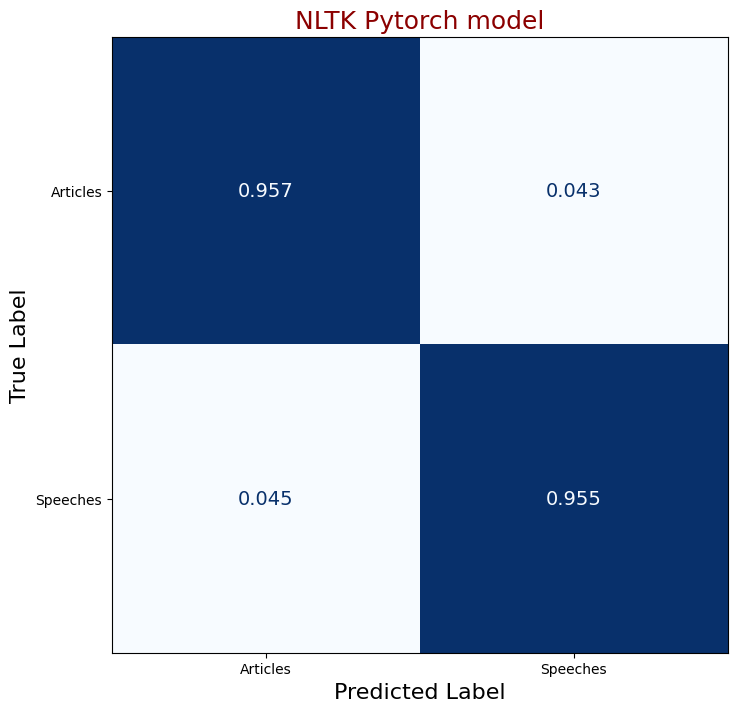

In [88]:
cm = skm.confusion_matrix(data_test_labels, predictions > 0.02, normalize='true')
classes = ["Articles", "Speeches"]
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax = ax, xticks_rotation=0, cmap=plt.cm.Blues, colorbar=False, values_format=".3f")
for t in disp.text_.ravel():
    t.set_fontsize(14)
plt.title("NLTK Pytorch model", fontsize=18, color="darkred")
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)
plt.savefig("confusion_matrix_speeches.png", dpi=300)
plt.show()

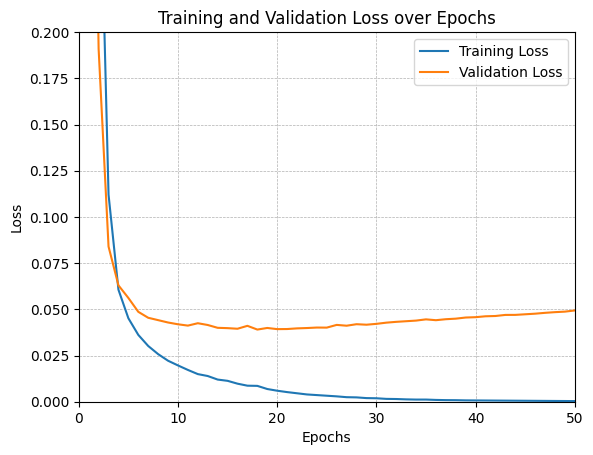

In [153]:
epochs = np.arange(1, n_epochs+1)
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.ylim(0, 0.2)
plt.xlim(0, 50)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

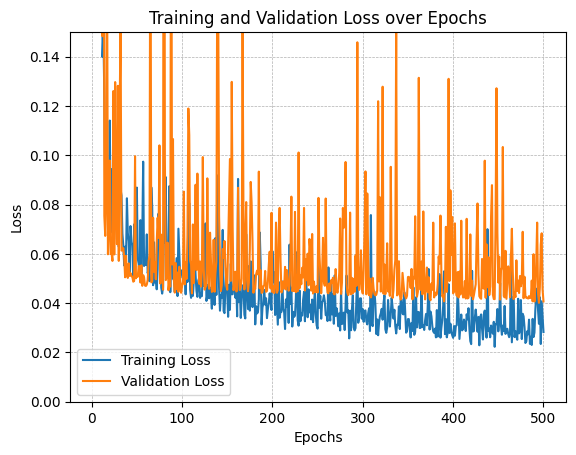

In [59]:
epochs = np.arange(1, n_epochs+1)
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.ylim(0., 0.15)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
learning_rate = 3e-6   
batch_size    = 16    
n_epochs      = 4     
class SpeechModelNLTK(nn.Module):
    def __init__(self):
        super(SpeechModelNLTK, self).__init__()       
        self.input_layer = nn.Linear(2001, 512)     
        self.hidden_layer1 = nn.Linear(512, 256)
        self.hidden_layer2 = nn.Linear(256, 32)
        self.output_layer = nn.Linear(32, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
learning_rate = 7e-05   
batch_size    = 64    
n_epochs      = 10    
class SermonModelNLTK(nn.Module):
    def __init__(self):
        super(SermonModelNLTK, self).__init__()       
        self.input_layer = nn.Linear(7328, 256)     
        self.hidden_layer1 = nn.Linear(256, 128)
        self.hidden_layer2 = nn.Linear(128, 8)
        self.output_layer = nn.Linear(8, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
learning_rate = 1e-5   
batch_size    = 16    
n_epochs      = 4     
class SpeechModel(nn.Module):
    def __init__(self):
        super(SpeechModel, self).__init__()       
        self.input_layer = nn.Linear(2000, 512)     
        self.hidden_layer1 = nn.Linear(512, 256)
        self.hidden_layer2 = nn.Linear(256, 128)
        self.output_layer = nn.Linear(128, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
learning_rate = 7e-05   
batch_size    = 64    
n_epochs      = 20    
class SermonModel(nn.Module):
    def __init__(self):
        super(SermonModel, self).__init__()       
        self.input_layer = nn.Linear(251, 512)     
        self.hidden_layer1 = nn.Linear(512, 128)
        self.hidden_layer2 = nn.Linear(128, 12)
        self.output_layer = nn.Linear(12, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x